In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px

In [2]:
# ==============================
# CONFIGURACIÓN
# ==============================

assets = ["SAN.MC", "BBVA.MC", "^IBEX", "^GSPC"]
start_date = "2019-01-01"
end_date = "2026-01-01"
trading_days = 252 # Número típico de días de trading en un año (excluyendo fines de semana y festivos)
risk_free_rate = 0.02  # 2% anual

In [3]:
# ==============================
# DESCARGA DE PRECIOS AJUSTADOS
# ==============================

data = yf.download(
    assets,
    start=start_date,
    end=end_date,
    auto_adjust=True # Descarga precios ajustados automáticamente (dividendos y splits incluidos)
)

# Extraer precios de cierre ajustados correctamente
if isinstance(data.columns, pd.MultiIndex):
    prices = data["Close"]
else:
    prices = data["Close"]

prices = prices.dropna() # Eliminamos días donde falten datos en algún activo

[*********************100%***********************]  4 of 4 completed


In [4]:

# ==============================
# RETORNOS DIARIOS SIMPLES
# ==============================

daily_returns = prices.pct_change().dropna()

In [5]:

# ==============================
# RETORNOS DIARIOS ACUMULADOS
# ==============================

cumulative_returns = (1 + daily_returns).cumprod() - 1
print("\n=== RETORNOS DIARIOS ACUMULADOS ===\n")
print(cumulative_returns.tail())  # muestra últimas filas

# Si quieres guardarlo:
# cumulative_returns.to_csv("retornos_acumulados.csv")


=== RETORNOS DIARIOS ACUMULADOS ===

Ticker       BBVA.MC    SAN.MC     ^GSPC     ^IBEX
Date                                              
2025-12-23  5.302349  2.311517  1.752871  1.009684
2025-12-24  5.295974  2.307213  1.761740  1.008526
2025-12-29  5.308725  2.299597  1.751258  1.011205
2025-12-30  5.401172  2.352571  1.747473  1.029813
2025-12-31  5.391608  2.334030  1.727258  1.024304


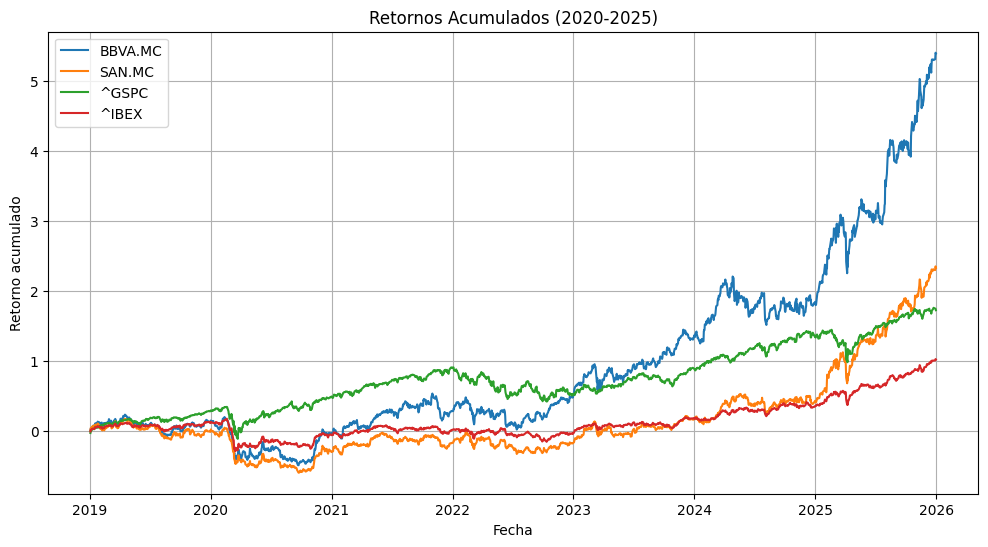

In [6]:

# ==============================
# GRÁFICO DE RETORNOS ACUMULADOS
# ==============================

plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns)
plt.title("Retornos Acumulados (2020-2025)")
plt.xlabel("Fecha")
plt.ylabel("Retorno acumulado")
plt.legend(cumulative_returns.columns)
plt.grid(True)
plt.show()

In [7]:
# ==============================
# VOLATILIDAD ANUALIZADA
# ==============================

vol_annual = daily_returns.std() * np.sqrt(trading_days)

# Convertir a porcentaje
vol_annual = vol_annual * 100

print("\n=== VOLATILIDAD ANUALIZADA (2020-2025) ===\n")
print(vol_annual.round(2).astype(str) + " %")


=== VOLATILIDAD ANUALIZADA (2020-2025) ===

Ticker
BBVA.MC    35.98 %
SAN.MC     35.35 %
^GSPC      19.97 %
^IBEX      19.35 %
dtype: str


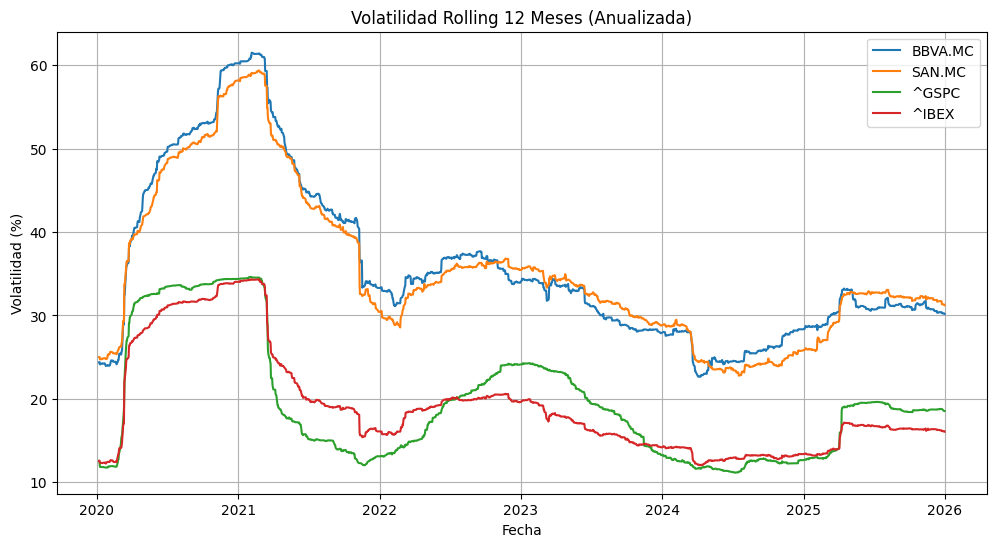

In [8]:
# ==================================
# GRÁFICO DE VOLATILIDAD ROLLING 12M
# ==================================

rolling_vol_12m = (
    daily_returns
    .rolling(window=252) # Ventana de 252 días para volatilidad móvil (aprox. 12 meses)
    .std()
    * np.sqrt(trading_days)
)

# Convertir a porcentaje
rolling_vol_12m = rolling_vol_12m * 100

plt.figure(figsize=(12,6))
plt.plot(rolling_vol_12m)
plt.title("Volatilidad Rolling 12 Meses (Anualizada)")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad (%)")
plt.legend(rolling_vol_12m.columns)
plt.grid(True)
plt.show()

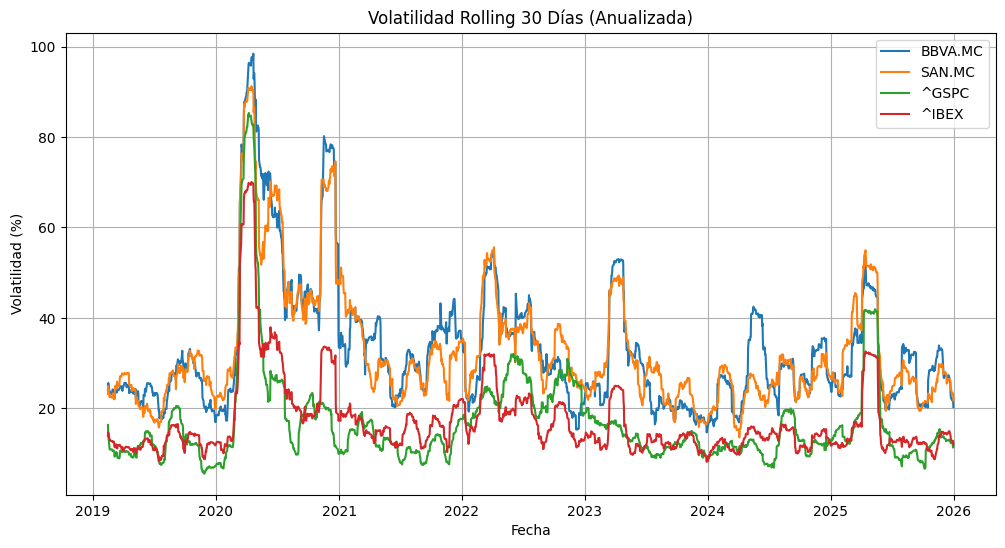

In [9]:
# ==================================
# GRÁFICO DE VOLATILIDAD ROLLING 30D
# ==================================

rolling_vol_30d = (
    daily_returns
    .rolling(window=30) # Ventana de 30 días para volatilidad móvil
    .std()
    * np.sqrt(trading_days) # Escalamos a anualizada usando el número de días de trading en un año
)

# Convertir a porcentaje
rolling_vol_30d = rolling_vol_30d * 100

plt.figure(figsize=(12,6))
plt.plot(rolling_vol_30d)
plt.title("Volatilidad Rolling 30 Días (Anualizada)")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad (%)")
plt.legend(rolling_vol_30d.columns)
plt.grid(True)
plt.show()

In [10]:
# 
# ==============================
# SHARPE RATIO
# ==============================

rf_daily = risk_free_rate / trading_days # Convertimos tasa anual a diaria dividiendo por número de días de trading
excess_returns = daily_returns - rf_daily # Exceso de retorno diario

# Media diaria de exceso
mean_excess_daily = excess_returns.mean()

# Sharpe anualizado directo
sharpe_ratio = (
    mean_excess_daily / daily_returns.std()
) * np.sqrt(trading_days)

print("\n=== SHARPE RATIO 2019-2026 ===\n")
print(sharpe_ratio.round(3))


=== SHARPE RATIO 2019-2026 ===

Ticker
BBVA.MC    0.871
SAN.MC     0.613
^GSPC      0.727
^IBEX      0.522
dtype: float64


Con estos Sharpe:

- BBVA ≈ 0.87 → Muy sólido

- Banco Santander ≈ 0.61 → Correcto

- S&P 500 ≈ 0.73 → Consistente con mercado fuerte

- IBEX 35 ≈ 0.52 → Más modesto

In [11]:
print(mean_excess_daily)
print(daily_returns.std())

Ticker
BBVA.MC    0.001243
SAN.MC     0.000860
^GSPC      0.000576
^IBEX      0.000400
dtype: float64
Ticker
BBVA.MC    0.022662
SAN.MC     0.022267
^GSPC      0.012578
^IBEX      0.012188
dtype: float64


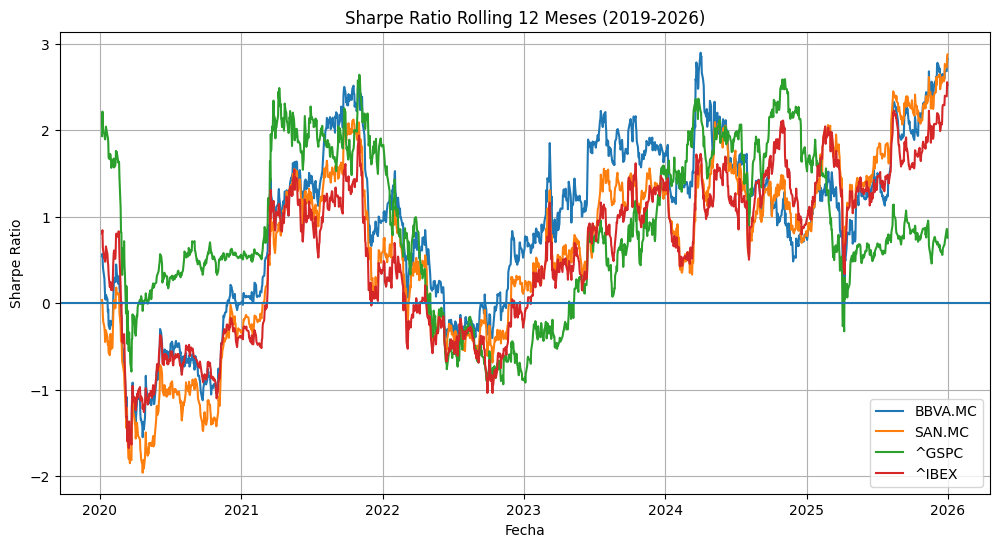

In [12]:
# ==============================
# GRÁFICO DE SHARPE ROLLING 12M
# ==============================

rolling_mean = excess_returns.rolling(252).mean() * trading_days
rolling_vol = daily_returns.rolling(252).std() * np.sqrt(trading_days)

rolling_sharpe = rolling_mean / rolling_vol

# ==============================
# GRÁFICO
# ==============================

plt.figure(figsize=(12,6))
plt.plot(rolling_sharpe)
plt.title("Sharpe Ratio Rolling 12 Meses (2019-2026)")
plt.xlabel("Fecha")
plt.ylabel("Sharpe Ratio")
plt.legend(rolling_sharpe.columns)
plt.axhline(0)
plt.grid(True)
plt.show()

In [13]:
# ==================================================================
# GRÁFICO INTERACTIVO COMPARANDO SHARPE ROLLING 12M CON SHARPE TOTAL
# ==================================================================

fig = go.Figure()

for ticker in assets:
    
    # Sharpe rolling
    fig.add_trace(go.Scatter(
        x=rolling_sharpe.index,
        y=rolling_sharpe[ticker],
        mode='lines',
        name=f"{ticker} Rolling 12M"
    ))
    
    # Línea horizontal Sharpe total
    fig.add_trace(go.Scatter(
        x=rolling_sharpe.index,
        y=[sharpe_ratio[ticker]] * len(rolling_sharpe),
        mode='lines',
        name=f"{ticker} Sharpe Total",
        line=dict(dash="dash")
    ))

fig.update_layout(
    title="Sharpe Ratio Rolling 12M vs Sharpe Total (2019-2026)",
    yaxis_title="Sharpe Ratio",
    xaxis_title="Fecha",
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

pio.write_html(
    fig,
    file="sharpe_rolling_2019_2026.html",
    auto_open=True,
    include_plotlyjs="cdn"
)

In [15]:
# =====================
# MATRIZ DE CORRELACIÓN
# =====================
correlation_matrix = daily_returns.corr()

print("=== MATRIZ DE CORRELACIÓN ===")
print(correlation_matrix.round(3))

=== MATRIZ DE CORRELACIÓN ===
Ticker   BBVA.MC  SAN.MC  ^GSPC  ^IBEX
Ticker                                
BBVA.MC    1.000   0.838  0.392  0.808
SAN.MC     0.838   1.000  0.399  0.837
^GSPC      0.392   0.399  1.000  0.511
^IBEX      0.808   0.837  0.511  1.000


In [ ]:
# ==================================
# HEATMAP INTERACTIVO DE CORRELACIÓN
# ==================================

fig_corr = px.imshow(
    correlation_matrix,
    text_auto=True,
    aspect="auto",
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1
)

fig_corr.update_layout(
    title="Matriz de Correlación (2019-2026)",
)

fig_corr.show()

# Guardar como HTML
fig_corr.write_html("correlacion_2019_2026.html", auto_open=True)